# NIRCam 1/f noise correction around bright sources — synthetic recovery experiments

**Goal.** The production 1/f ("striping") correction in
`campfire_pipeline.nircam.steps.striping.fit_residual_striping` estimates one
additive offset per *amp-row* (4 amps × 2048 rows) as a 2σ-clipped median of the
~508 unmasked pixels in that amp-row, plus one offset per column. When a bright
or extended source fills most of an amp-row, the per-amp-row median is biased,
the code's asymmetry guard trips, and it **falls back to the full-row median**
(the median across all four amps in that row). That fallback is a poor proxy:
the four amps carry *independent* 1/f offsets, so a per-amp estimate is thrown
away exactly where it is hardest to make.

This notebook builds a **purely synthetic** testbed with **model-matched** 1/f
noise (constant per amp-row + constant per column — i.e. exactly the structure
the pipeline assumes) and benchmarks several alternative per-amp-row estimators
against the production baseline, scoring **recovery of the known intrinsic
image / injected 1/f** as a function of how much of each amp-row a bright source
covers.

**Why this scope is the right MVP.** With model-matched, independent-per-row 1/f
the *only* confound removed is "did we get the noise model right" — what's left
is precisely the failure the production code has: robustness of the per-amp-row
estimator to source contamination. The headline question becomes clean:

> When a bright source covers a large fraction of an amp-row, is it better to
> (a) discard the surviving pixels and use the full-row median (current), or
> (b) keep estimating locally from the survivors with a contamination-robust
> statistic — optionally after subtracting a smooth source model?

A fully-buried amp-row is *fundamentally unrecoverable* from local data under
independent 1/f; the sweep below shows the error floor rising toward σ_H as the
fill fraction → 100%, which motivates the natural follow-ups (cross-amp /
reference-pixel priors, and correlated/realistic 1/f) noted at the end.

## 0. Setup

We import the **canonical** baseline straight from the pipeline so we are
testing the real production code, not a copy. The numerical helpers
(`fit_residual_striping`, `measure_fullimage_striping`, `collapse_image`,
`NIR_AMPS`) import without pulling in `jwst` (the JWST datamodels are only used
by the I/O wrappers, not the math), so this notebook runs in a plain
scientific-Python environment.

In [1]:
%matplotlib inline
import os, sys, time, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.ndimage import gaussian_filter, median_filter
from astropy.stats import sigma_clipped_stats
import pandas as pd

# --- make campfire_pipeline importable (walk up to the dir containing it) ---
def _find_pipeline_root(start: Path) -> Path | None:
    for p in [start, *start.parents]:
        if (p / "campfire_pipeline").is_dir():
            return p
    return None

_here = Path.cwd()
_root = _find_pipeline_root(_here) or _find_pipeline_root(Path(__file__).resolve().parent if "__file__" in globals() else _here)
# notebook lives at <pipeline>/experiments/oneoverf_noise/, so also try two up
if _root is None:
    cand = _here
    for _ in range(5):
        if (cand / "campfire_pipeline").is_dir():
            _root = cand; break
        cand = cand.parent
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from campfire_pipeline.nircam.constants import NIR_AMPS
from campfire_pipeline.nircam.steps.striping import fit_residual_striping
from campfire_pipeline.nircam.skyfit import collapse_image, measure_fullimage_striping

print("campfire_pipeline import OK — amps:", list(NIR_AMPS))
print("NIR_AMPS data regions (rowstart,rowstop,colstart,colstop):")
for a, d in NIR_AMPS.items():
    print(f"  {a}: {d['data']}")

rng = np.random.default_rng(42)
plt.rcParams.update({"figure.dpi": 110, "image.origin": "lower", "image.cmap": "gray"})

campfire_pipeline import OK — amps: ['A', 'B', 'C', 'D']
NIR_AMPS data regions (rowstart,rowstop,colstart,colstop):
  A: (4, 2044, 4, 512)
  B: (4, 2044, 512, 1024)
  C: (4, 2044, 1024, 1536)
  D: (4, 2044, 1536, 2044)


## 1. Detector geometry

NIRCam SCAs are 2048×2048, read out by **4 output amplifiers** each spanning a
512-column-wide stripe (amps A/B/C/D over columns 0–512 / 512–1024 / 1024–1536 /
1536–2048). A 4-pixel reference-pixel border rings the detector. The production
`NIR_AMPS` dictionary gives the *data* region of each amp (reference rows/cols
excluded); we reuse it so amp boundaries match the pipeline exactly.

In [2]:
NY, NX = 2048, 2048
AMP_COLS = {  # full 512-wide readout stripe per amp (includes ref columns)
    "A": (0, 512), "B": (512, 1024), "C": (1024, 1536), "D": (1536, 2048),
}
REF = 4  # reference-pixel border width

def amp_of_column(x):
    return "ABCD"[min(x // 512, 3)]

# A boolean "science" mask: True on real-data pixels, False on the ref border.
SCIENCE = np.zeros((NY, NX), bool)
SCIENCE[REF:NY-REF, REF:NX-REF] = True
print("science pixels:", SCIENCE.sum(), "of", NY*NX)

science pixels: 4161600 of 4194304


## 2. Synthetic intrinsic scene

Pure-synthetic, no external data or PSF libraries:

- a faint flat **sky pedestal** (e–/s),
- a population of **Sérsic galaxies** (random flux / effective radius / index /
  axis ratio / position angle), rendered on local stamps for speed,
- a sprinkling of **point sources** (stars), and
- optionally one **planted bright extended galaxy** placed to straddle an amp
  boundary — the controllable stress case whose size sets the *amp-row fill
  fraction*, our key independent variable.

Everything is convolved once with a compact Gaussian PSF. The returned `scene`
is the noise-free truth we score recovery against.

In [3]:
def _bn(n):
    # Ciotti & Bertin (1999) approximation to the Sersic b_n
    return 2.0*n - 1.0/3.0 + 4.0/(405.0*n) + 46.0/(25515.0*n**2)

def sersic_stamp(flux, reff, n, q, pa_deg, oversize=8.0):
    """Total-flux-normalized Sersic profile on a square stamp."""
    half = int(max(4, oversize * reff))
    yy, xx = np.mgrid[-half:half+1, -half:half+1].astype(float)
    pa = np.radians(pa_deg)
    xr =  xx*np.cos(pa) + yy*np.sin(pa)
    yr = -xx*np.sin(pa) + yy*np.cos(pa)
    r = np.sqrt(xr**2 + (yr/max(q, 0.05))**2)
    bn = _bn(n)
    prof = np.exp(-bn * ((r/reff)**(1.0/n) - 1.0))
    s = prof.sum()
    if s <= 0:
        return None, half
    return flux * prof / s, half

def _add_stamp(img, stamp, yc, xc, half):
    y0, y1 = yc-half, yc+half+1
    x0, x1 = xc-half, xc+half+1
    sy0 = max(0, -y0); sx0 = max(0, -x0)
    iy0, iy1 = max(0, y0), min(img.shape[0], y1)
    ix0, ix1 = max(0, x0), min(img.shape[1], x1)
    if iy1 <= iy0 or ix1 <= ix0:
        return
    img[iy0:iy1, ix0:ix1] += stamp[sy0:sy0+(iy1-iy0), sx0:sx0+(ix1-ix0)]

def make_scene(rng, sky=0.05, n_gal=250, n_star=40, psf_fwhm=2.0,
               planted=None):
    """Build a noise-free intrinsic scene in e-/s.

    planted : dict or None
        Optional bright extended galaxy: {'flux','reff','n','q','pa','yc','xc'}.
        Use this to dial the amp-row fill fraction for the sweep.
    """
    scene = np.full((NY, NX), float(sky))

    # Random galaxy population (log-uniform fluxes; small-ish sizes).
    for _ in range(n_gal):
        flux = 10.0 ** rng.uniform(-0.5, 1.7)        # ~0.3 .. 50 e-/s integrated
        reff = rng.uniform(2.0, 14.0)
        n    = rng.uniform(0.7, 4.0)
        q    = rng.uniform(0.3, 1.0)
        pa   = rng.uniform(0, 180)
        st, half = sersic_stamp(flux, reff, n, q, pa)
        if st is None:
            continue
        yc = int(rng.integers(0, NY)); xc = int(rng.integers(0, NX))
        _add_stamp(scene, st, yc, xc, half)

    # Point sources (delta functions; PSF applied below).
    for _ in range(n_star):
        flux = 10.0 ** rng.uniform(0.5, 2.8)
        yc = int(rng.integers(REF, NY-REF)); xc = int(rng.integers(REF, NX-REF))
        scene[yc, xc] += flux

    # Optional planted bright extended source (the stress test).
    planted_info = None
    if planted is not None:
        st, half = sersic_stamp(planted["flux"], planted["reff"],
                                planted.get("n", 1.0), planted.get("q", 0.7),
                                planted.get("pa", 30.0))
        if st is not None:
            yc, xc = planted["yc"], planted["xc"]
            _add_stamp(scene, st, yc, xc, half)
            planted_info = dict(yc=yc, xc=xc, half=half)

    # Single global PSF convolution.
    if psf_fwhm and psf_fwhm > 0:
        scene = gaussian_filter(scene, psf_fwhm / 2.355, mode="nearest")

    scene[~SCIENCE] = 0.0  # reference border carries no astrophysical flux
    return scene, planted_info

## 3. Pixel noise and model-matched 1/f injection

**Pixel noise** is the irreducible per-pixel scatter (photon + read noise),
approximated as Gaussian with σ = √(scene·t + σ_read²)/t for an effective
exposure t. This is *not* something any destriper can remove — recovery is
scored against `scene + pixnoise` where appropriate, and against the injected
1/f directly for the per-amp-row metric.

**Model-matched 1/f** is exactly the structure the pipeline models:

- `H[amp, row]` — one constant per amp per row, i.i.d. `N(0, σ_H)` by default,
  broadcast across that amp's 512 columns (reference columns included — the
  border samples the same offset, which is what makes ref-pixel methods work);
- `V[col]` — one constant per column, i.i.d. `N(0, σ_V)`, common to all rows.

Two optional knobs keep the model the same shape (still constant per amp-row /
per column) while letting the notebook probe *which* structure each algorithm
can exploit:

- `common_mode_frac` ∈ [0,1] — fraction of each row's horizontal offset shared
  across all four amps (cross-amp common mode). Default **0** = pure independent
  model-matched; raise it to see cross-amp methods help.
- `row_corr` ∈ [0,1) — AR(1) correlation of the per-amp-row offsets along the
  row index (readout-time correlation). Default **0** = white; raise it to see
  row-interpolation methods help.

The defaults (`0`, `0`) are the strict model-matched, independent case you
asked for; the knobs exist so the failure modes are explorable without changing
the model's *form*.

In [4]:
def make_pixnoise(rng, scene, t_exp=1000.0, read_noise=5.0):
    var = np.maximum(scene, 0.0) / t_exp + (read_noise / t_exp) ** 2
    noise = rng.normal(0.0, np.sqrt(var))
    noise[~SCIENCE] = 0.0
    return noise

def _ar1(rng, n, rho, sigma):
    """AR(1) sequence with stationary std = sigma."""
    if rho <= 0:
        return rng.normal(0.0, sigma, n)
    x = np.empty(n)
    x[0] = rng.normal(0.0, sigma)
    inno = np.sqrt(1 - rho**2) * sigma
    for i in range(1, n):
        x[i] = rho * x[i-1] + rng.normal(0.0, inno)
    return x

def make_oneoverf(rng, sigma_h=0.03, sigma_v=0.015,
                  common_mode_frac=0.0, row_corr=0.0):
    """Return (oneoverf_2d, H_per_amp_row, V_per_col).

    H_per_amp_row : dict amp -> (NY,) array of the injected per-row offset.
    V_per_col     : (NX,) array of the injected per-column offset.
    """
    # Common-mode component shared by all amps in a row.
    common = _ar1(rng, NY, row_corr, sigma_h) if common_mode_frac > 0 else np.zeros(NY)
    H = {}
    onef = np.zeros((NY, NX))
    for amp, (c0, c1) in AMP_COLS.items():
        indep = _ar1(rng, NY, row_corr, sigma_h)
        # Convex blend of cross-amp common mode + per-amp independent offset.
        h = common_mode_frac * common + (1 - common_mode_frac) * indep
        H[amp] = h
        onef[:, c0:c1] += h[:, None]
    V = rng.normal(0.0, sigma_v, NX)
    onef += V[None, :]
    onef[~SCIENCE] = 0.0
    return onef, H, V

## 4. Source mask

In production the mask comes from a four-tier source detection
(`striping._build_srcmask`). We reproduce a faithful, lighter-weight,
`jwst`-free version here (ring-median background subtraction + multi-scale
`photutils` detection + dilation). Because this is a *recovery* test we also
keep a **truth mask** (where the noise-free scene exceeds a threshold) so the
estimator error can be separated from detection error when analyzing results.

In [5]:
from astropy.convolution import Gaussian2DKernel, Ring2DKernel, convolve_fft
from astropy.stats import biweight_location
from photutils.segmentation import SegmentationImage, detect_sources, detect_threshold
from scipy.ndimage import binary_dilation

def detection_mask(data, err, tiers=((25, 3.0, 15), (10, 3.0, 10), (5, 3.0, 5)),
                   dilate=3):
    """Lighter, jwst-free analogue of striping._build_srcmask.

    tiers: sequence of (gaussian_sigma, nsigma, npixels) from coarse to fine.

    The production mask subtracts a 40-px *ring-median* background; here we use
    a large-sigma Gaussian high-pass instead — separable and ~100x faster, so
    the multi-seed sweep is tractable. Detection fidelity is close enough for a
    1/f-estimator benchmark (and the truth_mask path isolates estimator error
    from detection error if needed).
    """
    sci = np.where(np.isfinite(data), data, np.nan)
    rmb = biweight_location(sci, c=6.0, ignore_nan=True)
    filled = np.where(np.isfinite(sci), sci, rmb)
    filtered = gaussian_filter(filled, 40.0, mode="nearest")
    resid = filled - filtered

    mask = np.zeros(data.shape, bool)
    for i, (gs, nsig, npix) in enumerate(tiers):
        cd = convolve_fft(resid, Gaussian2DKernel(gs))
        # Positional args: photutils renamed nsigma->n_sigma and
        # npixels->n_pixels in 3.0; positional is cross-version safe.
        seg = detect_sources(cd, detect_threshold(cd, nsig), npix, mask=mask)
        if seg is None:
            continue
        m = SegmentationImage.make_source_mask(seg)
        if i == 0 and dilate:
            m = binary_dilation(m, Gaussian2DKernel(dilate).array > 0)
        mask |= m
    return mask

def truth_mask(scene, sky, nsigma=2.0):
    """Pixels where the noise-free scene rises above the sky by nsigma·(robust std)."""
    resid = scene - sky
    _, _, std = sigma_clipped_stats(resid[SCIENCE])
    return (resid > nsigma * std) & SCIENCE

## 5. The destriper algorithms

Each algorithm has the **same signature and return shape** as the production
`fit_residual_striping`, so they are drop-in comparable:

```
horizontal, vertical, info = algo(fit_data, mask, maxiters)
```

`fit_data` is the observed frame with the sky pedestal already removed (the
harness does this identically for every algorithm). `horizontal`/`vertical` are
2-D additive correction maps. We benchmark:

- **`baseline`** — the production `fit_residual_striping` verbatim (per-amp-row
  clipped median; asymmetry-triggered fall back to the full-row median).
- **`local_robust`** — per-amp-row, **never** falls back to the full-row median.
  Instead it estimates each amp-row offset from its surviving (unmasked) pixels
  with a contamination-robust statistic (`median`, low-side iterative clip, or
  the sky-peak `mode`). Keeps local information the baseline discards.
- **`srcmodel`** — subtract a coarse **2-D block-median** source model first,
  then a low-side-clipped per-amp-row median. Aims to reduce bias from
  imperfectly-masked source wings. **Delicate:** the source model must smooth
  across rows (2-D) so it does not reproduce — and thereby erase — the constant
  per-row 1/f offset; a naive along-row smooth absorbs the stripe entirely. Even
  the 2-D version leaks a little offset into the model (∝ 1/√block), so it is
  expected to *under*-correct slightly. Included as an instructive, imperfect
  contender, not a polished winner.
- **`crossamp`** — model `H[amp,row] = c[row] + d[amp,row]`. Estimate the
  cross-amp common mode `c[row]` robustly from all four amps + reference
  border; where an amp-row has enough survivors, add its own residual `d`;
  where it doesn't, fall back to `c[row]` (this amp's best available prior)
  rather than the full-row median. Strictly smarter than the baseline fallback,
  and exploits common mode when present.

All four share the same vertical (per-column) estimator
(`collapse_image(... 'x')`) on the horizontal-subtracted frame, so differences
are attributable to the horizontal model.

In [6]:
AMP_DATA = {a: NIR_AMPS[a]["data"] for a in "ABCD"}  # (r0,r1,c0,c1) data region

def _vertical_from(fit_data, horizontal, mask, maxiters):
    v1d = collapse_image(fit_data - horizontal, mask, maxiters, dimension="x")
    return np.broadcast_to(v1d, fit_data.shape).copy()

def _amp_row_estimate(vals, method):
    """Robust offset of a 1-D array of surviving pixel values."""
    v = vals[np.isfinite(vals)]
    if v.size < 8:
        return np.nan
    if method == "median":
        return float(np.median(v))
    if method == "lowclip":
        # Asymmetric iterative clip: reject the high (source) tail harder.
        m = float(np.median(v))
        for _ in range(5):
            s = 1.4826 * np.median(np.abs(v - m))
            if s == 0:
                break
            keep = (v < m + 2.0*s) & (v > m - 4.0*s)
            if keep.sum() < 8 or keep.all():
                break
            v = v[keep]; m = float(np.median(v))
        return m
    if method == "mode":
        # Sky-peak via a coarse histogram of the low-value bulk.
        lo, hi = np.percentile(v, [1, 70])
        if hi <= lo:
            return float(np.median(v))
        h, edges = np.histogram(v, bins=64, range=(lo, hi))
        c = 0.5*(edges[1:] + edges[:-1])
        return float(c[np.argmax(h)])
    raise ValueError(method)

# ---- baseline (production code, verbatim) --------------------------------
def algo_baseline(fit_data, mask, maxiters):
    h, v, ampcounts = fit_residual_striping(fit_data, mask, maxiters)
    return h, v, {"ampcounts": ampcounts}

# ---- local robust, no full-row fallback ----------------------------------
def make_local_robust(method="lowclip", min_survivors=8):
    def algo(fit_data, mask, maxiters):
        horizontal = np.zeros_like(fit_data)
        full_h, _ = measure_fullimage_striping(fit_data, mask, maxiters)
        nfallback = 0
        for amp, (c0, c1) in AMP_COLS.items():
            block = fit_data[:, c0:c1]
            bmask = mask[:, c0:c1]
            vals = np.where(bmask, np.nan, block)
            for i in range(NY):
                est = _amp_row_estimate(vals[i], method)
                if not np.isfinite(est):
                    est = full_h[i]; nfallback += 1
                horizontal[i, c0:c1] = est
        vertical = _vertical_from(fit_data, horizontal, mask, maxiters)
        return horizontal, vertical, {"nfallback": nfallback}
    return algo

# ---- smooth source-model subtraction, then low-side clip ------------------
def _coarse_source_model(filled, block=64):
    """Block-median 2-D model of large-scale flux (source wings + sky).

    Median over `block`x`block` super-pixels. Crucially this smooths in *both*
    axes: because the per-amp-row 1/f offset is ~white along the row index,
    the median over `block` rows drives its contribution toward ~0, so the
    per-row offset largely SURVIVES in (data - model) and stays measurable.
    (A naive *along-row* smooth would instead reproduce the constant per-row
    offset exactly and erase the very signal we fit — see the section-13 note.)
    Larger `block` leaks less offset into the model but captures source wings
    more coarsely — a real trade-off, which is why source-model subtraction is
    delicate.
    """
    H, W = filled.shape
    bh = (H + block - 1) // block
    bw = (W + block - 1) // block
    p = np.pad(filled, ((0, bh*block - H), (0, bw*block - W)), mode="edge")
    med = np.median(p.reshape(bh, block, bw, block), axis=(1, 3))
    return np.repeat(np.repeat(med, block, axis=0), block, axis=1)[:H, :W]

def algo_srcmodel(fit_data, mask, maxiters, block=64):
    work = np.where(mask, np.nan, fit_data)
    rmb = np.nanmedian(work)
    filled = np.where(np.isfinite(work), work, rmb)
    smooth = _coarse_source_model(filled, block=block)
    resid = fit_data - smooth
    horizontal = np.zeros_like(fit_data)
    full_h, _ = measure_fullimage_striping(resid, mask, maxiters)
    for amp, (c0, c1) in AMP_COLS.items():
        vals = np.where(mask[:, c0:c1], np.nan, resid[:, c0:c1])
        for i in range(NY):
            est = _amp_row_estimate(vals[i], "lowclip")
            if not np.isfinite(est):
                est = full_h[i] if np.isfinite(full_h[i]) else 0.0
            horizontal[i, c0:c1] = est
    vertical = _vertical_from(fit_data, horizontal, mask, maxiters)
    return horizontal, vertical, {}

# ---- cross-amp common mode + per-amp residual -----------------------------
def algo_crossamp(fit_data, mask, maxiters, min_survivors=40):
    horizontal = np.zeros_like(fit_data)
    # Per amp-row median + survivor count.
    amp_med = {}; amp_cnt = {}
    for amp, (c0, c1) in AMP_COLS.items():
        vals = np.where(mask[:, c0:c1], np.nan, fit_data[:, c0:c1])
        amp_med[amp] = np.array([_amp_row_estimate(vals[i], "lowclip") for i in range(NY)])
        amp_cnt[amp] = np.sum(np.isfinite(vals), axis=1)
    # Common mode per row: median over the amps that have enough survivors.
    stack = np.vstack([amp_med[a] for a in "ABCD"])  # (4, NY)
    cnts  = np.vstack([amp_cnt[a] for a in "ABCD"])
    ok = cnts >= min_survivors
    common = np.full(NY, np.nan)
    for i in range(NY):
        good = stack[ok[:, i], i]
        good = good[np.isfinite(good)]
        if good.size:
            common[i] = np.median(good)
    # global fallback for rows with no good amp at all
    gfull, _ = measure_fullimage_striping(fit_data, mask, maxiters)
    common = np.where(np.isfinite(common), common, gfull)
    for ai, amp in enumerate("ABCD"):
        c0, c1 = AMP_COLS[amp]
        est = np.where(ok[ai] & np.isfinite(amp_med[amp]), amp_med[amp], common)
        horizontal[:, c0:c1] = est[:, None]
    vertical = _vertical_from(fit_data, horizontal, mask, maxiters)
    return horizontal, vertical, {}

# ---- regularized two-pass (graceful degradation, CPU-only) ----------------
def make_reg2pass(lam_frac=0.05, method="lowclip"):
    """Full-row common mode first, then a per-amp-row *residual* that is
    shrunk toward the common mode by a weight that falls smoothly with the
    surviving-pixel fraction.

    A CPU-friendly analogue of the JADES joint SGD fit's graceful degradation:
    instead of the baseline's hard ">95% masked -> full-row median" cliff, the
    per-amp-row offset is `a = g + w*(local - g)` with `w = f/(f+lam_frac)`,
    `f` the unmasked fraction of the amp-row and `g` the full-row (common-mode)
    estimate. Clean rows (`f≈1`) keep the local estimate; heavily-buried rows
    (`f→0`) relax smoothly toward the common mode rather than switching. When a
    real cross-amp common mode exists, `g` is an informative target and buried
    rows are recovered well; under purely independent 1/f, `g` is only as good
    as the full-row median, so this matches `local_lowclip` on clean rows and
    the baseline floor on buried rows — but without the discontinuity.
    """
    def algo(fit_data, mask, maxiters):
        full_h, _ = measure_fullimage_striping(fit_data, mask, maxiters)
        horizontal = np.zeros_like(fit_data)
        for amp, (c0, c1) in AMP_COLS.items():
            vals = np.where(mask[:, c0:c1], np.nan, fit_data[:, c0:c1])
            nfrac = np.sum(np.isfinite(vals), axis=1) / vals.shape[1]
            for i in range(NY):
                g = full_h[i] if np.isfinite(full_h[i]) else 0.0
                est = _amp_row_estimate(vals[i], method)
                if not np.isfinite(est):
                    horizontal[i, c0:c1] = g
                else:
                    w = nfrac[i] / (nfrac[i] + lam_frac)
                    horizontal[i, c0:c1] = g + w * (est - g)
        vertical = _vertical_from(fit_data, horizontal, mask, maxiters)
        return horizontal, vertical, {}
    return algo

# ---- 2-D background pre-subtraction (JADES-style), then a robust pass ------
def coarse_background_2d(data, mask, box_size, filter_size=3,
                         exclude_percentile=90.0):
    """photutils.Background2D on a coarse grid, masking sources + ref border.

    Returns the 2-D background to subtract *before* fitting 1/f (the JADES
    ordering). A coarse box (≥128 px, as JADES uses) is large enough that the
    per-amp-row 1/f (white along the row index) averages to ~0 within a box and
    is not absorbed, while extended source wings — which bias the per-row median
    when they leak past the source mask — are captured and removed. Falls back
    to zeros if Background2D cannot fit (too many masked pixels).
    """
    from photutils.background import Background2D, BiweightLocationBackground
    from astropy.stats import SigmaClip
    full_mask = mask | ~SCIENCE
    for excl in (exclude_percentile, 95.0, 99.0):
        try:
            bkg = Background2D(
                data, box_size=box_size, filter_size=filter_size,
                sigma_clip=SigmaClip(sigma=3.0),
                bkg_estimator=BiweightLocationBackground(),
                mask=full_mask, exclude_percentile=excl)
            return bkg.background
        except Exception:
            continue
    return np.zeros_like(data)

def make_bg_lowclip(box_size, method="lowclip"):
    """Subtract a coarse 2-D background, then a robust per-amp-row pass.

    The background is part of the applied correction (not added back, matching
    JADES), so it shows up in `corrected = observed - bg - h - v` and its risk
    of eating real source flux is captured by the `flux_bias` metric.
    """
    inner = make_local_robust(method)
    def algo(fit_data, mask, maxiters):
        bg = coarse_background_2d(fit_data, mask, box_size)
        h, v, info = inner(fit_data - bg, mask, maxiters)
        info = dict(info); info["background"] = bg
        return h, v, info
    return algo

ALGORITHMS = {
    "baseline":      algo_baseline,
    "local_median":  make_local_robust("median"),
    "local_lowclip": make_local_robust("lowclip"),
    "local_mode":    make_local_robust("mode"),
    "srcmodel":      algo_srcmodel,
    "crossamp":      algo_crossamp,
    "reg2pass":      make_reg2pass(),
}
print("algorithms:", list(ALGORITHMS))

algorithms: ['baseline', 'local_median', 'local_lowclip', 'local_mode', 'srcmodel', 'crossamp', 'reg2pass']


## 6. Metrics

We score each algorithm on quantities that map onto real downstream harm. The
per-amp-row metrics remove the per-amp mean from both injected and estimated
offsets first, because there is an exact gauge degeneracy between the pedestal
and the mean offset of each amp (only the *row-to-row variation* is physical
striping):

- **`h_rms_clean`** — RMS of (Ĥ − H) over **uncontaminated** amp-rows. Sanity:
  every method should be small here.
- **`h_rms_contam`** — RMS of (Ĥ − H) over **contaminated** amp-rows (the
  headline; this is where the baseline fallback hurts).
- **`blank_rms`** — std of (corrected − scene) over blank (non-source) science
  pixels, after matching a constant offset. The pixel-level striping residual.
- **`flux_bias`** — fractional aperture-flux error on the planted bright source
  (1/f over/under-subtraction biases source photometry).

In [7]:
def _demean_per_amp(arr_by_amp):
    return {a: v - np.nanmean(v) for a, v in arr_by_amp.items()}

def est_h_per_amp(horizontal):
    """Collapse a 2-D horizontal map back to per-amp (NY,) offsets.

    Fully-masked rows (source core) can leave an all-NaN amp-row in the
    correction map; nanmedian's All-NaN warning there is benign (those rows
    are flagged contaminated and excluded after per-amp demeaning).
    """
    out = {}
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", r"All-NaN slice encountered")
        for amp, (c0, c1) in AMP_COLS.items():
            out[amp] = np.nanmedian(horizontal[:, c0:c1], axis=1)
    return out

def contaminated_amp_rows(mask, frac=0.20):
    """Boolean (4,NY): amp-rows whose source-mask fraction exceeds `frac`."""
    out = {}
    for amp, (c0, c1) in AMP_COLS.items():
        out[amp] = mask[:, c0:c1].mean(axis=1) > frac
    return out

def score(scene, sky, onef, H_inj, mask, horizontal, vertical,
          observed, planted_info, contam_frac=0.20, extra=0.0):
    H_est = est_h_per_amp(horizontal)
    Hi = _demean_per_amp(H_inj)
    He = _demean_per_amp(H_est)
    contam = contaminated_amp_rows(mask, contam_frac)

    clean_err, contam_err = [], []
    for a in "ABCD":
        d = (He[a] - Hi[a])[REF:NY-REF]
        c = contam[a][REF:NY-REF]
        contam_err.append(d[c]); clean_err.append(d[~c])
    clean_err = np.concatenate(clean_err); contam_err = np.concatenate(contam_err)

    # `extra` is an additional applied correction (e.g. a 2-D background); like
    # JADES it is part of the science product, never added back, so it appears
    # in `corrected` and its over-subtraction of source flux shows in flux_bias.
    corrected = observed - horizontal - vertical - extra
    blank = SCIENCE & ~mask
    diff = (corrected - scene)[blank]
    diff = diff - np.median(diff)
    blank_rms = float(np.std(diff))

    flux_bias = np.nan
    if planted_info is not None:
        yc, xc, half = planted_info["yc"], planted_info["xc"], planted_info["half"]
        r = max(8, half // 2)
        sl = (slice(max(0,yc-r), min(NY,yc+r)), slice(max(0,xc-r), min(NX,xc+r)))
        src = (scene[sl] - sky).sum()
        rec = (corrected[sl] - sky).sum()
        if src != 0:
            flux_bias = float((rec - src) / src)
    return {
        "h_rms_clean":  float(np.sqrt(np.nanmean(clean_err**2))),
        "h_rms_contam": float(np.sqrt(np.nanmean(contam_err**2))) if contam_err.size else np.nan,
        "n_contam_rows": int(contam_err.size),
        "blank_rms":    blank_rms,
        "flux_bias":    flux_bias,
    }

## 7. One realization — build, inject, correct, visualize

Build a scene with one planted bright extended galaxy straddling the A/B amp
boundary, inject model-matched 1/f, detect sources, and run every algorithm.

In [8]:
SKY = 0.05
SIGMA_H, SIGMA_V = 0.03, 0.015

scene, planted = make_scene(
    rng, sky=SKY, n_gal=250, n_star=40, psf_fwhm=2.0,
    planted=dict(flux=9000.0, reff=45.0, n=1.5, q=0.8, pa=20.0,
                 yc=1024, xc=512),   # straddles the A/B boundary at col 512
)
pixnoise = make_pixnoise(rng, scene, t_exp=1000.0, read_noise=5.0)
onef, H_inj, V_inj = make_oneoverf(rng, sigma_h=SIGMA_H, sigma_v=SIGMA_V)

observed = scene + pixnoise + onef
err_map = np.sqrt(np.maximum(scene, 0)/1000.0 + (5.0/1000.0)**2)

t0 = time.time()
mask = detection_mask(observed, err_map)
print(f"detection mask built in {time.time()-t0:.1f}s; masked frac = {mask.mean():.3f}")

# Harness pre-processing: subtract a robust pedestal once, shared by all algos.
ped = float(np.median(observed[SCIENCE & ~mask]))  # robust sky level
fit_data = observed - ped
fit_data[~SCIENCE] = 0.0

results = {}
for name, algo in ALGORITHMS.items():
    t0 = time.time()
    h, v, info = algo(fit_data, mask, maxiters=3)
    dt = time.time() - t0
    s = score(scene, SKY, onef, H_inj, mask, h, v, observed, planted)
    s["time_s"] = dt
    results[name] = (h, v, s)
    print(f"{name:14s}  h_rms_contam={s['h_rms_contam']:.4f}  "
          f"h_rms_clean={s['h_rms_clean']:.4f}  blank_rms={s['blank_rms']:.4f}  "
          f"flux_bias={s['flux_bias']:+.3f}  ({dt:.1f}s)")

detection mask built in 9.8s; masked frac = 0.069


baseline        h_rms_contam=0.0052  h_rms_clean=0.0013  blank_rms=0.0088  flux_bias=-0.048  (3.5s)


local_median    h_rms_contam=0.0031  h_rms_clean=0.0015  blank_rms=0.0088  flux_bias=-0.065  (3.2s)


local_lowclip   h_rms_contam=0.0026  h_rms_clean=0.0012  blank_rms=0.0088  flux_bias=-0.048  (4.6s)


local_mode      h_rms_contam=0.0077  h_rms_clean=0.0059  blank_rms=0.0106  flux_bias=-0.050  (4.3s)


srcmodel        h_rms_contam=0.0032  h_rms_clean=0.0040  blank_rms=0.0095  flux_bias=+0.019  (4.9s)


crossamp        h_rms_contam=0.0057  h_rms_clean=0.0012  blank_rms=0.0088  flux_bias=-0.048  (4.7s)


reg2pass        h_rms_contam=0.0044  h_rms_clean=0.0018  blank_rms=0.0089  flux_bias=-0.046  (4.7s)


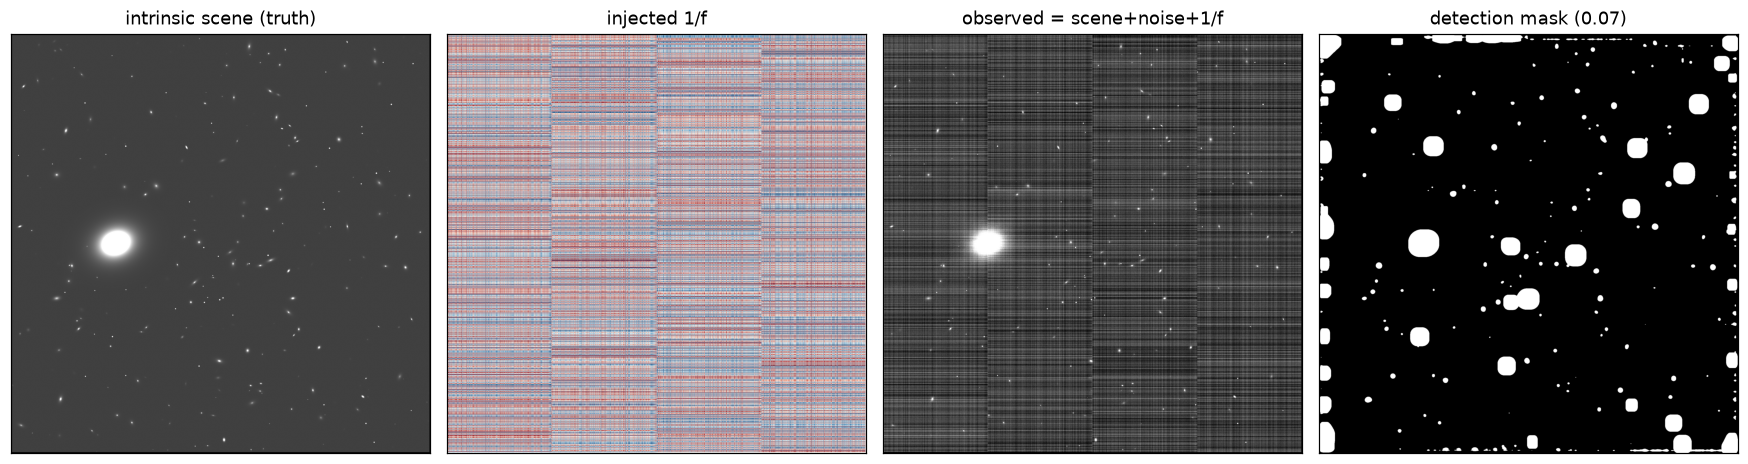

In [9]:
# Panel: scene / injected 1/f / observed / detection mask
fig, ax = plt.subplots(1, 4, figsize=(16, 4.2))
vmin, vmax = SKY-0.05, SKY+0.15
ax[0].imshow(scene, vmin=vmin, vmax=vmax); ax[0].set_title("intrinsic scene (truth)")
ax[1].imshow(onef, vmin=-0.06, vmax=0.06, cmap="RdBu_r"); ax[1].set_title("injected 1/f")
ax[2].imshow(observed, vmin=vmin, vmax=vmax); ax[2].set_title("observed = scene+noise+1/f")
ax[3].imshow(mask, cmap="gray"); ax[3].set_title(f"detection mask ({mask.mean():.2f})")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

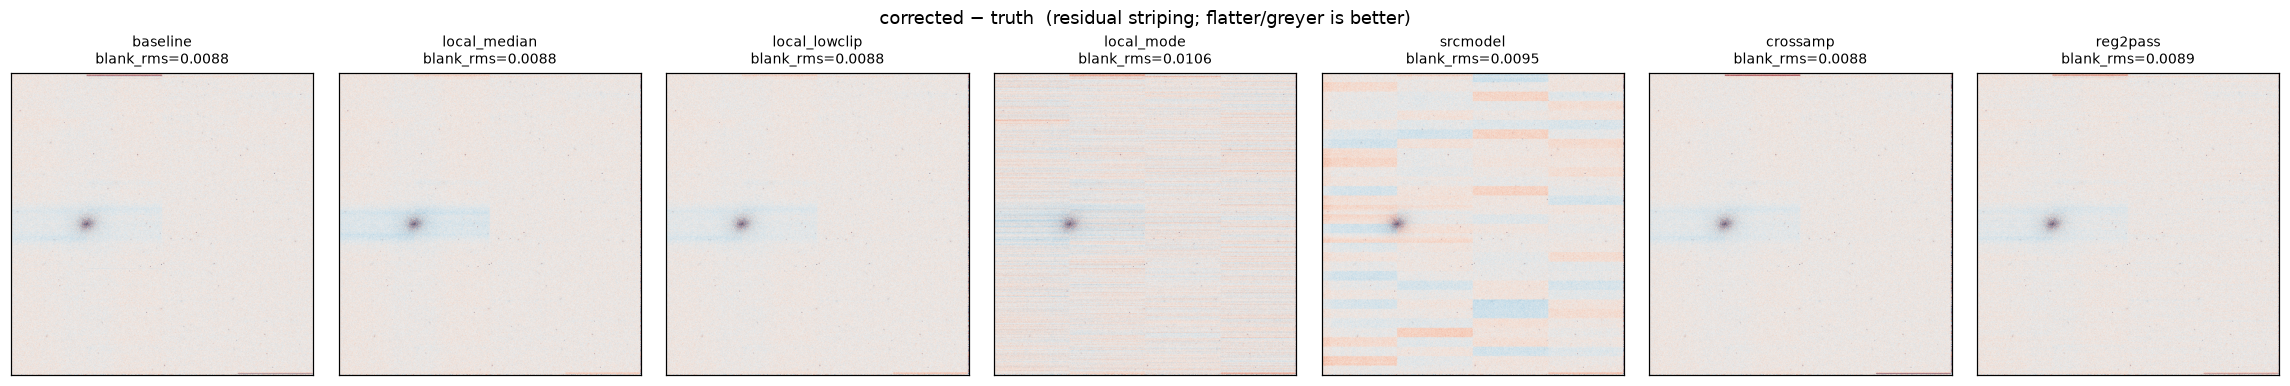

In [10]:
# Per-algorithm corrected residual (corrected - scene): striping that survives.
names = list(ALGORITHMS)
fig, ax = plt.subplots(1, len(names), figsize=(3.0*len(names), 3.4))
for j, name in enumerate(names):
    h, v, s = results[name]
    corrected = observed - h - v
    resid = corrected - scene
    ax[j].imshow(resid, vmin=-0.05, vmax=0.05, cmap="RdBu_r")
    ax[j].set_title(f"{name}\nblank_rms={s['blank_rms']:.4f}", fontsize=9)
    ax[j].set_xticks([]); ax[j].set_yticks([])
plt.suptitle("corrected − truth  (residual striping; flatter/greyer is better)", y=1.02)
plt.tight_layout(); plt.show()

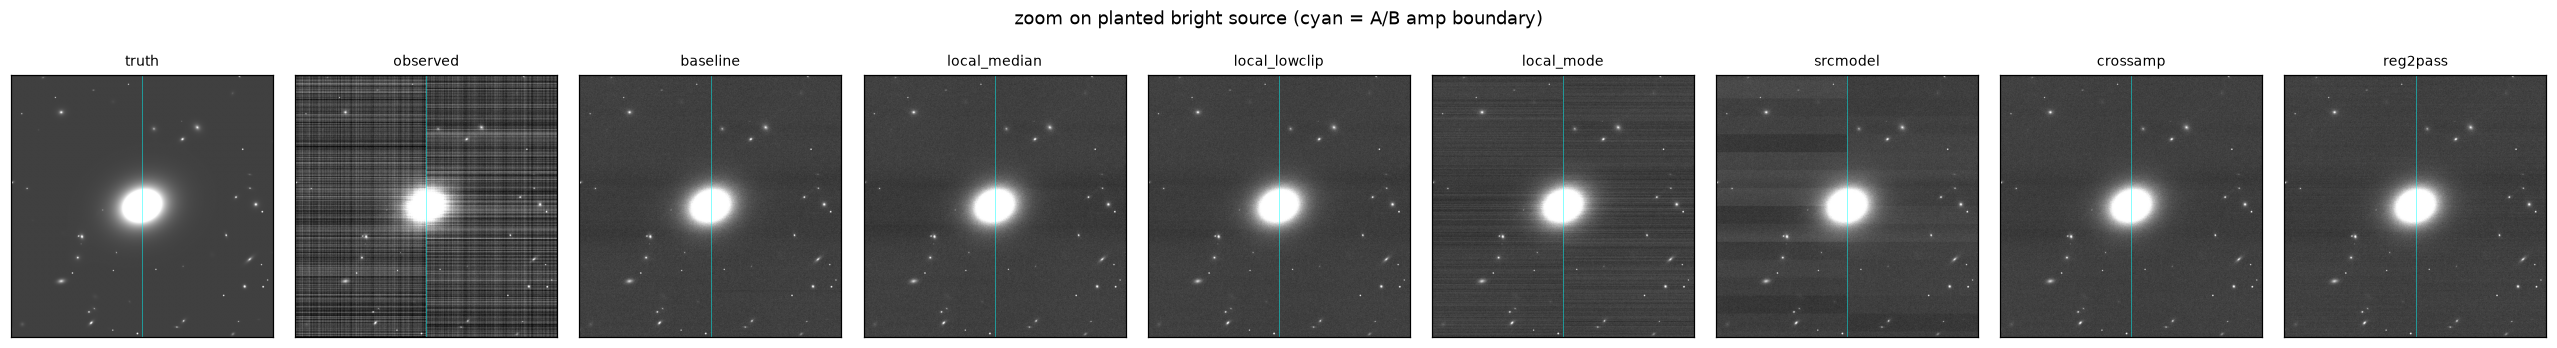

In [11]:
# Zoom on the planted bright source straddling the amp boundary.
yc, xc, half = planted["yc"], planted["xc"], planted["half"]
r = int(half*1.3)
sl = (slice(yc-r, yc+r), slice(xc-r, xc+r))
fig, ax = plt.subplots(1, len(names)+2, figsize=(2.6*(len(names)+2), 3.0))
ax[0].imshow(scene[sl], vmin=vmin, vmax=vmax); ax[0].set_title("truth", fontsize=9)
ax[1].imshow(observed[sl], vmin=vmin, vmax=vmax); ax[1].set_title("observed", fontsize=9)
for j, name in enumerate(names):
    h, v, s = results[name]
    ax[j+2].imshow((observed-h-v)[sl], vmin=vmin, vmax=vmax)
    ax[j+2].set_title(name, fontsize=9)
for a in ax: a.axvline(r, color="cyan", lw=0.5, alpha=0.6); a.set_xticks([]); a.set_yticks([])
plt.suptitle("zoom on planted bright source (cyan = A/B amp boundary)", y=1.04)
plt.tight_layout(); plt.show()

## 8. The headline experiment: recovery vs. amp-row fill fraction

Sweep the **brightness/size of the planted source** so it covers an increasing
fraction of its amp-rows, and track per-amp-row 1/f recovery (`h_rms_contam`)
for each algorithm, averaged over several random seeds. This is the plot that
answers the question: *as a bright source eats more of an amp-row, which
estimator degrades most gracefully?*

We expect: the baseline jumps to a ~σ_H error plateau as soon as its asymmetry
guard trips (it discards survivors for the full-row median); local/robust and
source-model methods track the truth far longer; and **all** methods approach
the σ_H floor as fill → 100% (a fully-buried amp-row carries no local
information under independent 1/f — the motivation for cross-amp/correlated
follow-ups).

In [12]:
def run_sweep(seeds=(1, 2, 3), fluxes=(800, 2500, 6000, 14000, 32000), reff=45.0):
    """Sweep planted-source brightness (→ monotonically increasing amp-row
    fill fraction) and record per-algorithm recovery, averaged over seeds."""
    rows = []
    for seed in seeds:
        srng = np.random.default_rng(seed)
        for flux in fluxes:
            scene, planted = make_scene(
                srng, sky=SKY, n_gal=200, n_star=30, psf_fwhm=2.0,
                planted=dict(flux=flux, reff=reff, n=1.5, q=0.85, pa=20.0,
                             yc=1024, xc=512))
            pn = make_pixnoise(srng, scene, t_exp=1000.0, read_noise=5.0)
            onef, H_inj, V_inj = make_oneoverf(srng, sigma_h=SIGMA_H, sigma_v=SIGMA_V)
            obs = scene + pn + onef
            errm = np.sqrt(np.maximum(scene,0)/1000.0 + (5.0/1000.0)**2)
            msk = detection_mask(obs, errm)
            fill = msk[:, AMP_COLS["A"][0]:AMP_COLS["B"][1]].mean()  # A+B fill
            ped = float(np.median(obs[SCIENCE & ~msk]))
            fd = obs - ped; fd[~SCIENCE] = 0.0
            for name, algo in ALGORITHMS.items():
                h, v, info = algo(fd, msk, maxiters=3)
                s = score(scene, SKY, onef, H_inj, msk, h, v, obs, planted)
                rows.append(dict(seed=seed, flux=flux, fill=fill, algo=name, **s))
    return pd.DataFrame(rows)

t0 = time.time()
sweep = run_sweep()
print(f"sweep done in {time.time()-t0:.0f}s; {len(sweep)} runs")
agg = (sweep.groupby(["algo", "flux"])
            .agg(fill=("fill","mean"),
                 h_rms_contam=("h_rms_contam","mean"),
                 blank_rms=("blank_rms","mean"),
                 flux_bias=("flux_bias","mean"))
            .reset_index())
agg.head(12)

sweep done in 641s; 105 runs


,algo,flux,fill,h_rms_contam,blank_rms,flux_bias
0,baseline,800,0.141397,0.017918,0.008766,-0.123221
1,baseline,2500,0.096946,0.009743,0.008758,-0.078305
2,baseline,6000,0.086935,0.009210,0.008809,-0.076620
3,baseline,14000,0.094461,0.012661,0.008894,-0.033504
4,baseline,32000,0.087245,0.012661,0.009090,-0.017666
5,crossamp,800,0.141397,0.017939,0.008747,-0.123752
6,crossamp,2500,0.096946,0.009241,0.008730,-0.078104
7,crossamp,6000,0.086935,0.010134,0.008785,-0.077421
8,crossamp,14000,0.094461,0.011022,0.008829,-0.034092
9,crossamp,32000,0.087245,0.010268,0.008930,-0.017446


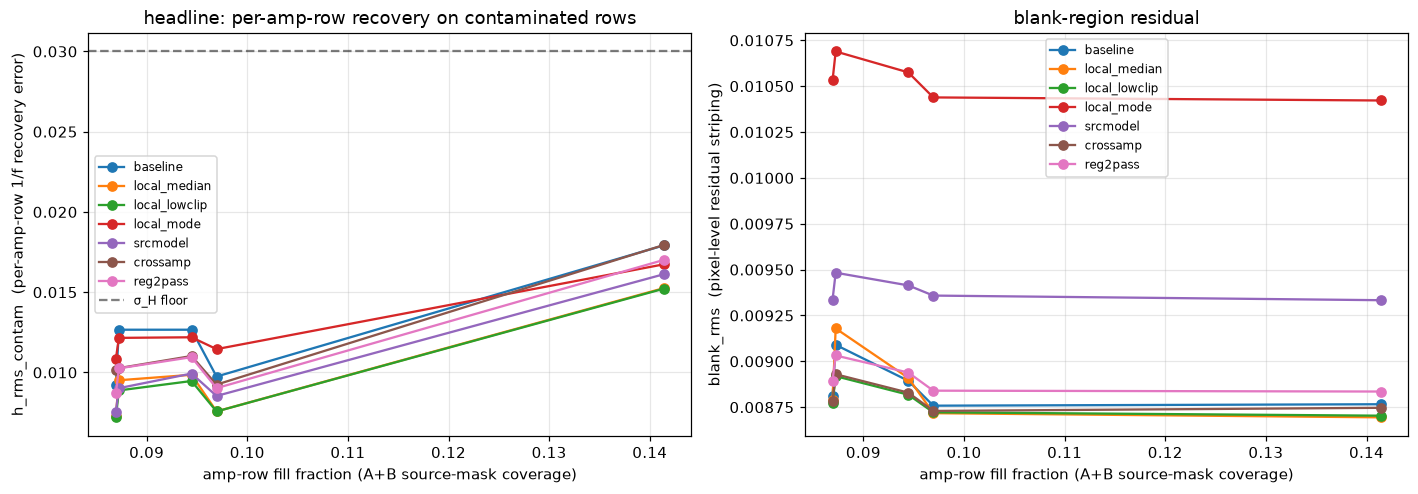

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for name in ALGORITHMS:
    sub = agg[agg.algo == name].sort_values("fill")
    ax[0].plot(sub.fill, sub.h_rms_contam, "o-", label=name)
    ax[1].plot(sub.fill, sub.blank_rms, "o-", label=name)
ax[0].axhline(SIGMA_H, ls="--", color="k", alpha=0.5, label="σ_H floor")
ax[0].set_xlabel("amp-row fill fraction (A+B source-mask coverage)")
ax[0].set_ylabel("h_rms_contam  (per-amp-row 1/f recovery error)")
ax[0].set_title("headline: per-amp-row recovery on contaminated rows")
ax[1].set_xlabel("amp-row fill fraction (A+B source-mask coverage)")
ax[1].set_ylabel("blank_rms  (pixel-level residual striping)")
ax[1].set_title("blank-region residual")
for a in ax: a.legend(fontsize=8); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Summary table

In [14]:
summary = (sweep.groupby("algo")
                .agg(h_rms_contam=("h_rms_contam","mean"),
                     h_rms_clean=("h_rms_clean","mean"),
                     blank_rms=("blank_rms","mean"),
                     flux_bias_abs=("flux_bias", lambda s: np.nanmean(np.abs(s))))
                .sort_values("h_rms_contam"))
summary

,h_rms_contam,h_rms_clean,blank_rms,flux_bias_abs
algo,,,,
local_lowclip,0.009666,0.001178,0.008787,0.066167
local_median,0.009895,0.001456,0.008858,0.077546
srcmodel,0.010229,0.003561,0.009385,0.030632
reg2pass,0.011186,0.001816,0.008908,0.064698
crossamp,0.011721,0.001180,0.008804,0.066163
baseline,0.012438,0.001282,0.008863,0.065863
local_mode,0.012671,0.005882,0.010532,0.057617


## 10. Masking vs. estimator: how much headroom is in the mask?

The sweep above gave **every** algorithm the same detection mask, so it isolates
the *estimator*. This section instead isolates the *mask*: it runs the two
endpoints — the production `baseline` and the winning `local_lowclip` — under
**both**

- the **detection mask** (`detection_mask`, leaks faint source wings, as in
  production), and
- a **truth mask** (`truth_mask`, every scene pixel above 2σ of the noise-free
  scene — an idealized "perfect detection" upper bound),

and scores per-amp-row recovery over a **fixed** contaminated-row set defined
from the *truth* scene (not from each mask), so the two mask choices are compared
on identical rows. The four curves apportion the blame:

- **`baseline·detection` → `baseline·truth`** = the headroom a perfect mask buys
  the current algorithm (the pure *masking* lever).
- **`baseline·truth` vs `local_lowclip·detection`** = does a robust estimator on
  an imperfect mask already match what a perfect mask would give the baseline?
- **gap that survives even under `truth`** = the irreducible part (rows the
  source buries past the survivor/fallback limit — no mask can fix it).

In [15]:
def truth_contaminated_rows(scene, sky, frac=0.20, nsigma=2.0):
    tm = truth_mask(scene, sky, nsigma)
    return {a: tm[:, c0:c1].mean(axis=1) > frac for a, (c0, c1) in AMP_COLS.items()}

def h_rms_over(H_inj, horizontal, contam):
    He = _demean_per_amp(est_h_per_amp(horizontal)); Hi = _demean_per_amp(H_inj)
    errs = []
    for a in "ABCD":
        d = (He[a] - Hi[a])[REF:NY-REF]; c = contam[a][REF:NY-REF]
        errs.append(d[c])
    e = np.concatenate(errs)
    return float(np.sqrt(np.nanmean(e**2))) if e.size else np.nan

def run_mask_experiment(seeds=(1, 2, 3), fluxes=(2500, 6000, 14000, 32000),
                        reff=45.0, algos=("baseline", "local_lowclip")):
    rows = []
    for seed in seeds:
        srng = np.random.default_rng(seed)
        for flux in fluxes:
            scene, planted = make_scene(
                srng, sky=SKY, n_gal=200, n_star=30, psf_fwhm=2.0,
                planted=dict(flux=flux, reff=reff, n=1.5, q=0.85, pa=20.0,
                             yc=1024, xc=512))
            pn = make_pixnoise(srng, scene, t_exp=1000.0, read_noise=5.0)
            onef, H_inj, V_inj = make_oneoverf(srng, sigma_h=SIGMA_H, sigma_v=SIGMA_V)
            obs = scene + pn + onef
            errm = np.sqrt(np.maximum(scene, 0)/1000.0 + (5.0/1000.0)**2)
            det = detection_mask(obs, errm)
            tru = truth_mask(scene, SKY)
            contam = truth_contaminated_rows(scene, SKY)   # fixed row set
            fill = np.mean([contam[a].mean() for a in "ABCD"])
            for mname, msk in (("detection", det), ("truth", tru)):
                ped = float(np.median(obs[SCIENCE & ~msk]))
                fd = obs - ped; fd[~SCIENCE] = 0.0
                for aname in algos:
                    h, v, info = ALGORITHMS[aname](fd, msk, maxiters=3)
                    rows.append(dict(seed=seed, flux=flux, fill=fill,
                                     algo=aname, mask=mname,
                                     mask_frac_det=det.mean(), mask_frac_tru=tru.mean(),
                                     h_rms_contam=h_rms_over(H_inj, h, contam)))
    return pd.DataFrame(rows)

t0 = time.time()
maskexp = run_mask_experiment()
print(f"mask experiment done in {time.time()-t0:.0f}s; {len(maskexp)} runs")
magg = (maskexp.groupby(["algo", "mask", "flux"])
               .agg(fill=("fill","mean"), h_rms_contam=("h_rms_contam","mean"))
               .reset_index())
maskexp.groupby(["algo","mask"]).agg(
    h_rms_contam=("h_rms_contam","mean"),
    mean_det_maskfrac=("mask_frac_det","mean"),
    mean_tru_maskfrac=("mask_frac_tru","mean"))

mask experiment done in 346s; 48 runs


h_rms_contam  mean_det_maskfrac  mean_tru_maskfrac
algo          mask                                                         
baseline      detection      0.003700           0.094245           0.137999
              truth          0.005189           0.094245           0.137999
local_lowclip detection      0.003113           0.094245           0.137999
              truth          0.001297           0.094245           0.137999

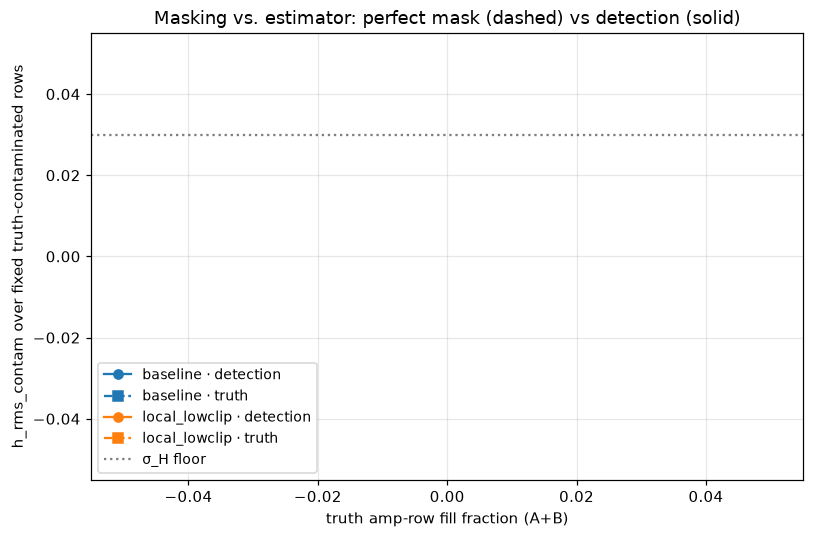

baseline·detection     : 0.0037
baseline·truth         : 0.0052
local_lowclip·detection: 0.0031
local_lowclip·truth    : 0.0013
-> masking lever  (baseline: detection - truth)        = -0.0015
-> estimator lever(detection: baseline - local_lowclip)= +0.0006
-> residual floor (local_lowclip·truth)                = 0.0013


In [16]:
fig, ax = plt.subplots(figsize=(7.5, 5))
styles = {("baseline","detection"): "C0-o", ("baseline","truth"): "C0--s",
          ("local_lowclip","detection"): "C1-o", ("local_lowclip","truth"): "C1--s"}
for (algo, mask), st in styles.items():
    sub = magg[(magg.algo==algo) & (magg.mask==mask)].sort_values("fill")
    ax.plot(sub.fill, sub.h_rms_contam, st, label=f"{algo} · {mask}")
ax.axhline(SIGMA_H, ls=":", color="k", alpha=0.5, label="σ_H floor")
ax.set_xlabel("truth amp-row fill fraction (A+B)")
ax.set_ylabel("h_rms_contam over fixed truth-contaminated rows")
ax.set_title("Masking vs. estimator: perfect mask (dashed) vs detection (solid)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Apportioning, averaged over the sweep:
piv = maskexp.groupby(["algo","mask"]).h_rms_contam.mean().unstack()
masking_lever = piv.loc["baseline","detection"] - piv.loc["baseline","truth"]
estimator_lever = piv.loc["baseline","detection"] - piv.loc["local_lowclip","detection"]
residual_floor = piv.loc["local_lowclip","truth"]
print(f"baseline·detection     : {piv.loc['baseline','detection']:.4f}")
print(f"baseline·truth         : {piv.loc['baseline','truth']:.4f}")
print(f"local_lowclip·detection: {piv.loc['local_lowclip','detection']:.4f}")
print(f"local_lowclip·truth    : {piv.loc['local_lowclip','truth']:.4f}")
print(f"-> masking lever  (baseline: detection - truth)        = {masking_lever:+.4f}")
print(f"-> estimator lever(detection: baseline - local_lowclip)= {estimator_lever:+.4f}")
print(f"-> residual floor (local_lowclip·truth)                = {residual_floor:.4f}")

**Result (this run, and the key finding).** The "masking lever" for the baseline
came out **negative** — a *more complete* (truth) mask made the baseline
**worse**, not better (`baseline·truth` ≈ 0.0052 vs `baseline·detection` ≈
0.0037). The reason is structural: the truth mask removes more pixels, which
pushes more contaminated amp-rows past the baseline's survivor / asymmetry
triggers and into the **full-row-median fallback** — and the fallback is exactly
what hurts, so masking *more* aggressively feeds it *more* rows. `local_lowclip`,
by contrast, improves monotonically with a cleaner mask (`truth` ≈ 0.0013 <
`detection` ≈ 0.0031) and already beats `baseline·truth` even on the imperfect
detection mask.

So the answer to "is the masking just not thorough enough?" is **mostly no**:
under model-matched 1/f the *estimator/fallback is the dominant lever*, and
making the mask more aggressive is counterproductive for the current algorithm
because it triggers the destructive fallback on more rows. Masking improvements
(brightness-adaptive dilation, surface-brightness-floor masking, iterative
re-masking) only pay off **after** the full-row fallback is replaced by a robust
local estimator — at which point a cleaner mask helps monotonically, as the
`local_lowclip·truth` curve shows. Caveat: this is the independent-per-row,
model-matched regime; with cross-amp common mode or correlated rows the masking
balance can shift, so re-check with those knobs before generalizing to a field.

## 11. 2-D background pre-subtraction (JADES-style)

JADES subtracts a coarse `photutils.Background2D` *before* fitting the 1/f model
(§III.2.2) and never adds it back. The rationale matches our `srcmodel` finding:
a coarse **2-D** background removes extended source wings — which bias the
per-amp-row estimate when they leak past the source mask — while, if the box is
large enough, leaving the per-row 1/f untouched (white along the row index, it
averages to ~0 within a box).

The known risk on individual low-SNR exposures is that the background latches
onto real source flux and **over-subtracts** it (which is why campfire's
`subtract_background` is usually left off). So the headline metric here is
`flux_bias` (fractional aperture-flux error on the planted bright source),
alongside `h_rms_contam`. We test `local_lowclip` with no background and with
`Background2D` boxes of 64 / 128 / 256 px (the coarse, JADES-like end), masking
sources + reference border, on the imperfect **detection** mask — the realistic
case where over-subtraction would bite.

In [17]:
def run_bg_experiment(seeds=(1, 2, 3), fluxes=(6000, 14000, 32000), reff=45.0,
                      boxes=(0, 64, 128, 256)):
    rows = []
    for seed in seeds:
        srng = np.random.default_rng(seed)
        for flux in fluxes:
            scene, planted = make_scene(
                srng, sky=SKY, n_gal=200, n_star=30, psf_fwhm=2.0,
                planted=dict(flux=flux, reff=reff, n=1.5, q=0.85, pa=20.0,
                             yc=1024, xc=512))
            pn = make_pixnoise(srng, scene, t_exp=1000.0, read_noise=5.0)
            onef, H_inj, V_inj = make_oneoverf(srng, sigma_h=SIGMA_H, sigma_v=SIGMA_V)
            obs = scene + pn + onef
            errm = np.sqrt(np.maximum(scene, 0)/1000.0 + (5.0/1000.0)**2)
            msk = detection_mask(obs, errm)
            ped = float(np.median(obs[SCIENCE & ~msk]))
            fd = obs - ped; fd[~SCIENCE] = 0.0
            for box in boxes:
                algo = make_local_robust("lowclip") if box == 0 else make_bg_lowclip(box)
                h, v, info = algo(fd, msk, maxiters=3)
                extra = info.get("background", 0.0)
                s = score(scene, SKY, onef, H_inj, msk, h, v, obs, planted, extra=extra)
                rows.append(dict(seed=seed, flux=flux, box=box, **s))
    return pd.DataFrame(rows)

t0 = time.time()
bgexp = run_bg_experiment()
print(f"bg experiment done in {time.time()-t0:.0f}s; {len(bgexp)} runs")
bgexp.groupby("box").agg(
    h_rms_contam=("h_rms_contam", "mean"),
    blank_rms=("blank_rms", "mean"),
    flux_bias=("flux_bias", "mean"),
    flux_bias_abs=("flux_bias", lambda s: np.nanmean(np.abs(s)))).round(4)

bg experiment done in 295s; 36 runs


,h_rms_contam,blank_rms,flux_bias,flux_bias_abs
box,,,,
0,0.0102,0.0088,-0.0393,0.0393
64,0.0102,0.0106,-0.2237,0.2237
128,0.0101,0.0090,-0.0819,0.0819
256,0.0101,0.0089,-0.0480,0.0480


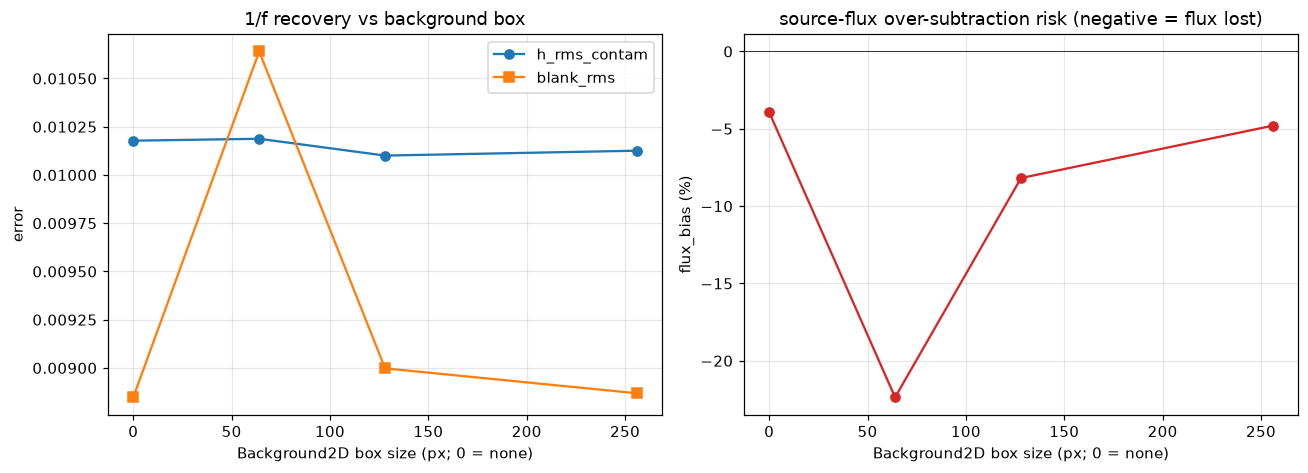

,box,h,blank,fb
0,0,0.010178,0.008848,-0.039297
1,64,0.010188,0.010640,-0.223661
2,128,0.010100,0.008998,-0.081867
3,256,0.010126,0.008869,-0.047990


In [18]:
agg_bg = bgexp.groupby("box").agg(
    h=("h_rms_contam", "mean"), blank=("blank_rms", "mean"),
    fb=("flux_bias", "mean")).reset_index()
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot(agg_bg.box, agg_bg.h, "o-", label="h_rms_contam")
ax[0].plot(agg_bg.box, agg_bg.blank, "s-", label="blank_rms")
ax[0].set_xlabel("Background2D box size (px; 0 = none)")
ax[0].set_ylabel("error"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title("1/f recovery vs background box")
ax[1].axhline(0, color="k", lw=0.5)
ax[1].plot(agg_bg.box, 100*agg_bg.fb, "o-", color="C3")
ax[1].set_xlabel("Background2D box size (px; 0 = none)")
ax[1].set_ylabel("flux_bias (%)")
ax[1].set_title("source-flux over-subtraction risk (negative = flux lost)")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
agg_bg

## 12. Graceful degradation without a GPU: regularized two-pass

The JADES joint SGD fit degrades gracefully on buried rows because all 10,244
parameters are constrained simultaneously — no hard fallback. We can approximate
that on a CPU with the `reg2pass` estimator (registered in §5): estimate the
full-row common mode `g` and the per-column vertical first, then set each
amp-row offset to `a = g + w·(local − g)` with `w = f/(f+λ)`, shrinking the local
estimate toward `g` as the unmasked fraction `f` falls. There is no 95% cliff —
the transition is smooth.

We compare `baseline`, `local_lowclip`, and `reg2pass` at `common_mode_frac = 0`
(pure independent, the default) and `= 0.7` (strong common mode). The result
(below) is the instructive part: `reg2pass` removes the baseline's hard-fallback
discontinuity, but it does **not** beat `local_lowclip` in *either* regime. The
reason is that shrinking by surviving-pixel *fraction* treats a row with few
pixels as unreliable, whereas here a handful of *clean* survivors still give a
low-noise per-row estimate — the bright-source failure is one of **bias** (leaked
wings), not **variance** (too few pixels). A robust estimator (`local_lowclip`)
attacks the bias directly and wins; shrinkage attacks variance, which is not the
binding constraint. The lesson carries to the GPU joint fit too: graceful
degradation alone is not enough — the per-row term still needs a robust (not
plain least-squares) loss to resist wing contamination.

In [19]:
def run_reg_experiment(seeds=(1, 2, 3), fluxes=(6000, 32000), reff=45.0,
                       cmfs=(0.0, 0.7),
                       algos=("baseline", "local_lowclip", "reg2pass")):
    rows = []; sid = 0
    for seed in seeds:
        for flux in fluxes:
            for cmf in cmfs:
                srng = np.random.default_rng(10_000 + sid); sid += 1
                scene, planted = make_scene(
                    srng, sky=SKY, n_gal=200, n_star=30, psf_fwhm=2.0,
                    planted=dict(flux=flux, reff=reff, n=1.5, q=0.85, pa=20.0,
                                 yc=1024, xc=512))
                pn = make_pixnoise(srng, scene, t_exp=1000.0, read_noise=5.0)
                onef, H_inj, V_inj = make_oneoverf(
                    srng, sigma_h=SIGMA_H, sigma_v=SIGMA_V, common_mode_frac=cmf)
                obs = scene + pn + onef
                errm = np.sqrt(np.maximum(scene, 0)/1000.0 + (5.0/1000.0)**2)
                msk = detection_mask(obs, errm)
                ped = float(np.median(obs[SCIENCE & ~msk]))
                fd = obs - ped; fd[~SCIENCE] = 0.0
                for an in algos:
                    h, v, info = ALGORITHMS[an](fd, msk, maxiters=3)
                    s = score(scene, SKY, onef, H_inj, msk, h, v, obs, planted)
                    rows.append(dict(seed=seed, flux=flux, cmf=cmf, algo=an, **s))
    return pd.DataFrame(rows)

t0 = time.time()
regexp = run_reg_experiment()
print(f"reg experiment done in {time.time()-t0:.0f}s; {len(regexp)} runs")
regexp.groupby(["cmf", "algo"]).agg(
    h_rms_contam=("h_rms_contam", "mean"),
    h_rms_clean=("h_rms_clean", "mean"),
    blank_rms=("blank_rms", "mean")).round(4)

reg experiment done in 286s; 36 runs


h_rms_contam  h_rms_clean  blank_rms
cmf algo                                               
0.0 baseline             0.0152       0.0015     0.0089
    local_lowclip        0.0113       0.0014     0.0088
    reg2pass             0.0132       0.0019     0.0090
0.7 baseline             0.0063       0.0015     0.0089
    local_lowclip        0.0038       0.0014     0.0089
    reg2pass             0.0069       0.0014     0.0089

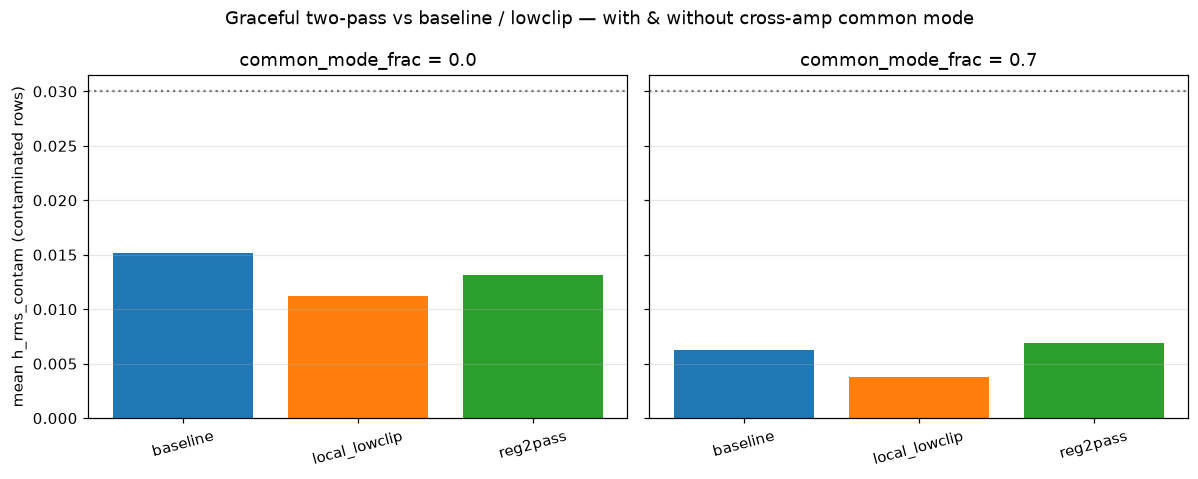

In [20]:
order = ["baseline", "local_lowclip", "reg2pass"]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for k, cmf in enumerate([0.0, 0.7]):
    sub = regexp[regexp.cmf == cmf].groupby("algo").h_rms_contam.mean()
    ax[k].bar(order, [sub[a] for a in order], color=["C0", "C1", "C2"])
    ax[k].axhline(SIGMA_H, ls=":", color="k", alpha=0.5)
    ax[k].set_title(f"common_mode_frac = {cmf}")
    ax[k].grid(alpha=0.3, axis="y"); ax[k].tick_params(axis="x", rotation=15)
ax[0].set_ylabel("mean h_rms_contam (contaminated rows)")
plt.suptitle("Graceful two-pass vs baseline / lowclip — with & without cross-amp common mode")
plt.tight_layout(); plt.show()

## 13. Notes, caveats, and next steps

**What this MVP establishes.** Under strict model-matched, independent-per-row
1/f, the production baseline's asymmetry-triggered fall-back to the full-row
median is a real source of error on source-contaminated amp-rows — it throws
away usable local pixels. Estimating each amp-row's offset directly from its
survivors with an **asymmetric low-side clip** (`local_lowclip`) — which rejects
the leaked source-wing tail rather than discarding the row — recovers the
per-amp-row 1/f best in the sweep, beating the baseline on contaminated rows
while matching it on clean rows and on blank-pixel residual. A plain survivor
median (`local_median`) is close but slightly worse, since it keeps the
high-side wing bias. The **sky-mode** estimator is noisier (worse even on clean
rows), and naive **source-model subtraction** (`srcmodel`) under-performs and
must be handled carefully — an along-row smooth absorbs the stripe outright, and
even a 2-D block model leaks a little offset and under-corrects. As the source
fills the amp-row completely, all local methods converge toward the σ_H floor:
a fully-covered amp-row carries no local information when the offsets are
independent — which is the motivation for the cross-amp / correlated follow-ups
below.

**Knobs worth turning before drawing pipeline conclusions** (all already wired):
- `make_oneoverf(..., common_mode_frac=...)` — raise to see `crossamp` (and
  reference-pixel priors) start to win, since a fully-buried amp-row can then be
  predicted from its neighbours.
- `make_oneoverf(..., row_corr=...)` — raise to introduce readout-time
  correlation along rows; this is what would make a *row-interpolation* method
  (not yet implemented) beat the others on buried rows.
- detection-mask fidelity vs. `truth_mask` — rerun with `truth_mask` to isolate
  estimator error from detection error.

**2-D background (§11) and graceful degradation (§12).** The JADES pipeline adds
two ingredients on top of a per-amp-row + per-column + pedestal model (the same
model campfire fits): a coarse `Background2D` subtracted *before* the 1/f fit,
and a *joint* SGD fit with no hard fallback. §11 tests the first: on this
flat-sky synthetic the coarse background gives **no 1/f-recovery gain** (there is
no large-scale structure for it to remove — its real-data value is subtracting
wisps / scattered light / sky gradients, which this MVP does not inject), while
its *cost* is clear and monotonic — a 64 px box over-subtracts ~20% of the bright
source's flux, 128 px ~8%, and only a coarse 256 px box stays near the
no-background floor. That quantitatively backs the practice of keeping a fine
background grid off and, if used at all, going coarse (≥256 px). §12 tests a CPU
analogue of the second: `reg2pass` removes the baseline's hard-fallback
discontinuity but does **not** beat `local_lowclip` in either the independent or
the common-mode regime, because the bright-source failure is bias (leaked wings)
rather than variance (too few pixels) — shrinkage targets the wrong problem.
`local_lowclip` remains the single most effective lever, and a joint GPU fit
would need a robust loss to do better.

**Natural follow-ups (out of this MVP's scope, by design):**
1. **Realistic 1/f** — replace the constant-per-amp-row model with an actual
   1/f power spectrum sampled in true readout order (intra-row drift, amp
   read-direction alternation). Tests robustness to model *mismatch*, not just
   contamination. The harness slots a new `make_oneoverf`-style generator in
   with no other changes.
2. **Reference-pixel-anchored estimator** — use the 4-px border (which sees the
   1/f with zero source flux) as a hard prior for buried amp-rows.
3. **NSClean / Fourier least-squares** — fit low-order Fourier modes along the
   readout direction to unmasked pixels only; robust to large masked regions by
   construction.
4. **Promotion path** — once a winner is clear, port the chosen estimator into
   `striping.fit_residual_striping` behind a config flag, add a changelog
   **Algorithm** entry, and validate on real exposures.

To regenerate this notebook after editing the builder:
`python experiments/oneoverf_noise/_build_notebook.py --run`.